In [23]:
# importing packages
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer



In [2]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\banig\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\banig\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
# target = {-1: 'negative', 1: 'positive', 0: 'neutral'}
df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv', encoding='latin-1')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [4]:
df.dropna(inplace=True)
df.drop_duplicates(inplace = True)
df = df[~(df['clean_comment'].str.strip()=='')]
    

In [5]:
def process_comment(comment):
    comment = comment.lower()
    comment = comment.strip()
    comment = re.sub(r'\n',' ', comment)
    comment = re.sub(r'[^A-Za-z0-9\s!?.,]', ' ', comment)
    stop_words = set(stopwords.words('english'))- set(['not', 'but','however','no','yes'])

    lemmatizer = WordNetLemmatizer()
    comment = " ".join([lemmatizer.lemmatize(word) for word in comment.split() if word not in stop_words])
    return comment

df['clean_comment'] = df['clean_comment'].apply(process_comment)


In [6]:
df.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [7]:
vectorizer= CountVectorizer(max_features=1000)
x = vectorizer.fit_transform(df['clean_comment']).toarray()
y = df['category']

In [8]:
x
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
mlflow.set_tracking_uri("http://15.135.159.216:5000/")
mlflow.set_experiment("Baseline RF")

<Experiment: artifact_location='s3://mlflow-bucket-sentiment/2', creation_time=1772082407567, experiment_id='2', last_update_time=1772082407567, lifecycle_stage='active', name='Baseline RF', tags={}>

Accuracy:0.6619105856774018


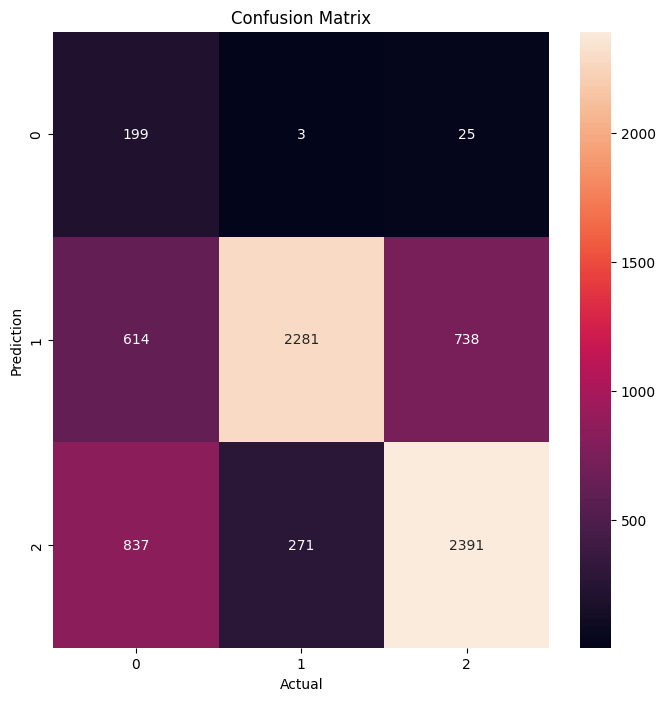

In [24]:
with mlflow.start_run() as run:
    mlflow.set_tag("mlflow.runName", "RandomForest Baseline Train")
    mlflow.set_tag("experiment type", "baseline")
    mlflow.set_tag("model type", "RandomForest Classifier")

    mlflow.log_param("vectorizer type", "countVectorizer")
    mlflow.log_param("vectorizer_max_feature", vectorizer.max_features)

    n_estimators = 200
    max_depth = 15

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    model = RandomForestClassifier(n_estimators = n_estimators, max_depth=max_depth)
    
    model.fit(train_x, train_y )

    prediction = model.predict(test_x)

    accuracy = accuracy_score(prediction, test_y)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(prediction,test_y, output_dict =True)
   

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):
            for metric, value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)



    save_dir =  os.getcwd()
    content_path = os.path.join(save_dir, "confusion_matrix.png")
    # confusion matrix plot
    conf_matrix = confusion_matrix(prediction, test_y)
    plt.figure(figsize =(8,8))
    sns.heatmap(conf_matrix,annot = True, fmt = "d")
    plt.xlabel("Actual")
    plt.ylabel("Prediction")
    plt.title("Confusion Matrix")
    plt.savefig(content_path)
    
    mlflow.log_artifact('confusion_matrix.png')

    df.to_csv("dataset.csv", index=False)
    mlflow.log_artifact("dataset.csv")

print(f"Accuracy:{accuracy}")

